# **1. Business Understanding**

## **1a. Latar Belakang**

Dalam industri E-Commerce yang sangat kompetitif, biaya untuk mengakuisisi pelanggan baru (*Customer Acquisition Cost* / CAC) diperkirakan 5 hingga 25 kali lebih mahal dibandingkan dengan biaya untuk mempertahankan pelanggan yang sudah ada (*Customer Retention*). Ketika seorang pelanggan berhenti melakukan transaksi atau berpindah ke platform pesaing, hal ini disebut sebagai **Customer Churn**.

Pendapatan utama E-Commerce bergantung pada siklus hidup pelanggan (*Customer Lifetime Value* / CLV). Semakin lama pelanggan aktif berbelanja, semakin tinggi profit yang didapatkan oleh perusahaan. Jika perusahaan gagal mengidentifikasi tanda-tanda pelanggan akan churn, mereka akan kehilangan pangsa pasar dan potensi pendapatan jangka panjang.

Biasanya, perusahaan E-Commerce melakukan upaya retensi dengan memberikan insentif seperti *cashback*, voucher diskon, atau promo gratis ongkir kepada pelanggan. Namun, jika insentif ini diberikan secara massal tanpa target yang jelas, hal ini akan membengkakkan biaya promosi (bakar uang).

## **1b. Rumusan Masalah**

Perusahaan E-Commerce HORU memiliki kumpulan data profil dan historis transaksi pelanggannya. Saat ini, perusahaan menyadari tingginya tingkat pelanggan yang *churn* (berhenti berbelanja).

Tanpa adanya sistem prediktif, tim marketing mencoba menahan pelanggan dengan cara membagikan voucher promosi secara acak kepada seluruh pengguna (atau berdasarkan tebakan manual). Cara ini menyebabkan dua masalah besar:
1. Banyak biaya promo terbuang sia-sia untuk pelanggan yang sebenarnya sudah loyal dan tidak berniat pindah (*waste of budget*).
2. Perusahaan seringkali terlambat menyadari pelanggan yang berisiko tinggi pindah, sehingga tidak ada penanganan khusus yang dilakukan sebelum pelanggan tersebut benar-benar pergi (*loss of revenue*).

Tim marketing merasa perlu melakukan perbaikan terhadap cara mereka menargetkan pelanggan untuk kampanye retensi. Dengan *budget* promosi yang terbatas, mereka menginginkan agar bisa mendapatkan daftar pelanggan yang benar-benar berisiko untuk *churn*, sehingga pemberian insentif bisa lebih tepat sasaran.

## **1c. Tujuan Bisnis**

Tujuan utama dari proyek ini adalah:

1. Bekerja sama dengan tim data untuk mengetahui gambaran umum terkait karakteristik dan pola perilaku pelanggan yang cenderung *churn* berdasarkan historis data.
2. Membangun model *Machine Learning* untuk memprediksi pelanggan mana saja yang potensial untuk *churn* di masa depan.
3. Tujuan utamanya adalah untuk meminimalisir angka *churn rate* demi menyelamatkan *Customer Lifetime Value* (CLV), sekaligus mengoptimalkan alokasi anggaran promosi retensi agar lebih efisien.


## **1d. Batasan & Metrik Model**

**Variabel Target :**

- 0 : no (pelanggan tetap bertahan / tidak churn)
- 1 : yes (pelanggan berhenti berbelanja / churn)

**Gambaran umum biaya dalam retensi pelanggan E-Commerce:**

Sebagai acuan untuk menentukan *cost & benefit*, berikut adalah asumsi rata-rata per pelanggan E-Commerce (angka estimasi):
- Rata-rata Profit per pelanggan yang aktif berbelanja (*Customer Lifetime Value*) : **$50 atau setara  Rp 500.000 / pelanggan**

- Biaya Promo Retensi (Voucher Diskon / Cashback) yang diberikan ke pelanggan : **$5 setara Rp 50.000 / pelanggan**.

**Evaluation Metrics:**

- _True Positive (TP)_ : Pelanggan yang diprediksi akan *churn* dan benar-benar *churn* (berhasil ditahan dengan promo).
- _False Positive (FP)_ : Pelanggan yang diprediksi akan *churn*, tetapi aktualnya setia (tidak *churn*).
- _True Negative (TN)_ : Pelanggan yang diprediksi setia dan benar-benar setia.
- _False Negative (FN)_ : Pelanggan yang diprediksi setia, tetapi aktualnya *churn* (gagal dicegah).
- Recall : mengukur seberapa banyak pelanggan churn yang berhasil diprediksi/ditangkap oleh model dari keseluruhan pelanggan yang benar-benar churn.

    Rumus Recall = TP / (TP + FN)

- Precision : mengukur seberapa akurat model dalam memprediksi pelanggan churn dibandingkan total prediksi churn yang dibuat.

    Rumus Precision = TP / (TP + FP)

- F1-Score : mengukur keseimbangan antara recall dan precision.

    Rumus F1-Score = 2 * (Recall * Precision) / (Recall + Precision)

- Type 1 Error (False Positive):

    Type 1 error : Pelanggan yang aktualnya setia, tetapi diprediksi akan churn.
    Konsekuensi : Perusahaan memberikan insentif/voucher kepada pelanggan yang sebenarnya tanpa diberi voucher pun akan tetap berbelanja.
    Kerugian biaya promosi sia-sia per pelanggan : Rp 50.000 (Biaya 1 Voucher).

- Type 2 Error (False Negative):

    Type 2 error : Pelanggan yang aktualnya berniat churn, tetapi diprediksi setia.
    Konsekuensi : Perusahaan gagal mendeteksi, tidak memberikan intervensi, dan pelanggan tersebut berhenti berbelanja selamanya.
    Kerugian kehilangan potensi pendapatan per pelanggan : Rp 500.000 (Kehilangan Profit CLV).

**Kesimpulan Metrics:**

Karena Type 2 Error (Kehilangan Pelanggan/Profit) menyebabkan kerugian finansial yang jauh lebih besar (10x lipat) dibandingkan dengan Type 1 Error (Rugi Voucher), maka metrik evaluasi yang akan diprioritaskan dalam model ini adalah Recall (Sensitivitas) untuk menekan angka False Negative seminimal mungkin.


# **2. Data Understanding**

## **2a. Sumber Data**


Data yang akan diolah dari link berikut = [link](https://drive.google.com/file/d/1LD8-45R_mAEiEvkLNbeM_m7Up-Yj0Nom/view?usp=sharing)

## **2b. Import Libraries**

In [39]:
# Import Library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Modules
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pickle

import warnings
warnings.filterwarnings('ignore')

## **2c. Upload Data**

In [2]:
data = pd.read_csv('data_ecommerce_customer_churn.csv')
data

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
...,...,...,...,...,...,...,...,...,...,...,...
3936,28.0,9.0,5,Fashion,3,Married,8,0,1.0,231.86,0
3937,8.0,7.0,2,Mobile Phone,2,Single,4,0,4.0,157.80,0
3938,30.0,6.0,5,Laptop & Accessory,3,Married,3,1,2.0,156.60,0
3939,6.0,NaN,4,Mobile,3,Married,10,1,0.0,124.37,1


## **2d. Tipe Data**

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


| **NAMA KOLOM** | **PENJELASAN** |
|----------------|----------------|
|Tenure | Lamanya pelanggan di perusahaan (bulan)|
|Warehouse To Home | Jarak Antara gudang dengan rumah pelanggan (km)|
|Number Of Device Registered | total perangkat yang terdaftar dengan pelanggan yang sama|
|Prefered Order Cat | kategori pesanan pelanggan 1 bulan yang lalu|
|Satisfaction Score | Nilai kepuasan pelanggan dalam hal pelayanan|
|Marital Status | status pernikahan pelanggan|
|Number Of Address | jumlah alamat dengan pelanggan yang sama|
|Complaint | komplain yang tersampaikan 1 bulan yang lalu|
|Day Since Last Order | jumlah hari setelah pelanggan transaksi|
|Cashback Amount | rata-rata cashback di bulan terakhir|
|Churn | status churn|


## **2e. Nilai Hilang**

In [4]:
datahilang = data.isna().sum()
datahilang

,0
Tenure,194
WarehouseToHome,169
NumberOfDeviceRegistered,0
PreferedOrderCat,0
SatisfactionScore,0
MaritalStatus,0
NumberOfAddress,0
Complain,0
DaySinceLastOrder,213
CashbackAmount,0


In [5]:
type(datahilang)

pandas.core.series.Series

In [6]:
datahilang.name = 'Total Data Hilang'
datahilang

,Total Data Hilang
Tenure,194
WarehouseToHome,169
NumberOfDeviceRegistered,0
PreferedOrderCat,0
SatisfactionScore,0
MaritalStatus,0
NumberOfAddress,0
Complain,0
DaySinceLastOrder,213
CashbackAmount,0


In [7]:
datahilang = pd.DataFrame(datahilang)
type(datahilang)

pandas.core.frame.DataFrame

In [8]:
datahilang['%'] = (datahilang['Total Data Hilang'] / len(data)) * 100
datahilang = datahilang.sort_values(by='Total Data Hilang',ascending=False)
datahilang

,Total Data Hilang,%
DaySinceLastOrder,213,5.404720
Tenure,194,4.922608
WarehouseToHome,169,4.288252
NumberOfDeviceRegistered,0,0.000000
PreferedOrderCat,0,0.000000
MaritalStatus,0,0.000000
SatisfactionScore,0,0.000000
NumberOfAddress,0,0.000000
Complain,0,0.000000
CashbackAmount,0,0.000000


<Axes: >

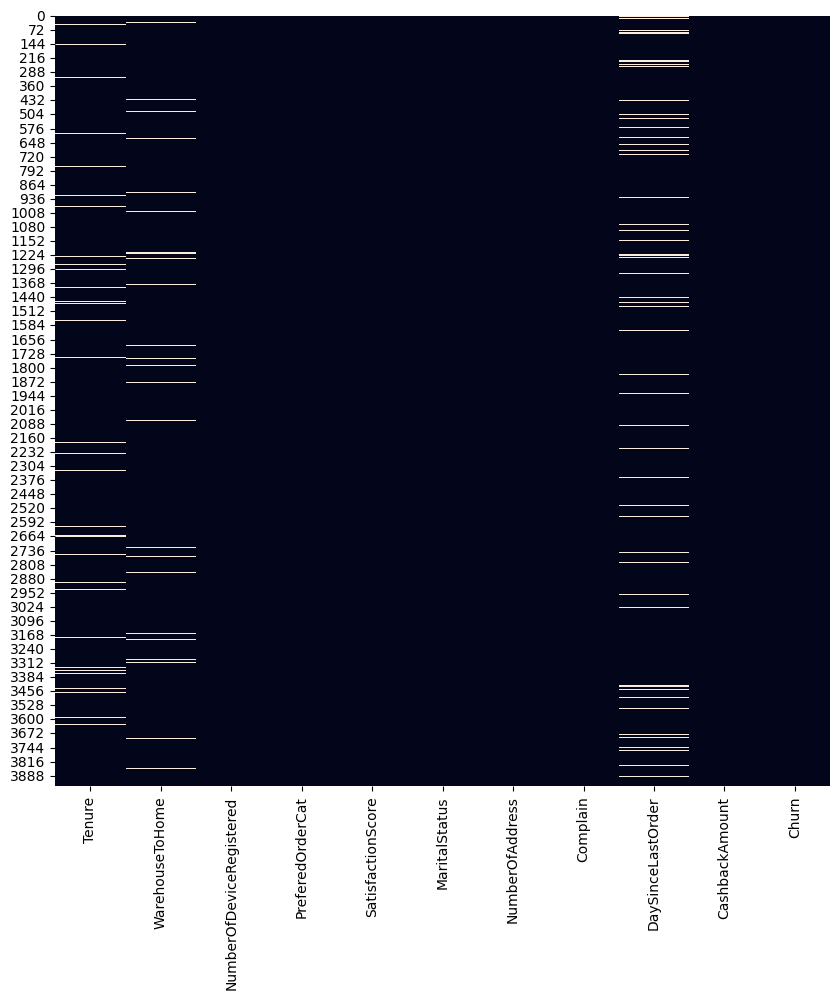

In [9]:
plt.figure(figsize=(10,10))
sns.heatmap(data.isna(),cbar=False)

## **2f. Nilai Duplikat**

In [10]:
data.duplicated().sum()

np.int64(671)

dari data duplikat, kita tidak bisa menghilangkan begitu saja data tersebut dikarenakan kita tidak bisa melihat apakah data yg terduplikat itu dalam satu customer atau tidak. bisa saja customer yang berbeda memiliki data yang sama

# **3. Exploratory Data Analysis (EDA) Part 1**

## **3a. Unique Data**

In [11]:
hasil = []

for col in data.columns:
        hasil.append({
            'column' : col,
            'type' : data[col].dtype,
            'missing_value' : data[col].isna().sum(),
            'missing_%' : data[col].isna().sum() / len(data) * 100,
            'unique' : data[col].nunique(),
            'unique_value' : data[col].unique()
      })
Hasil_data = pd.DataFrame(hasil)
pd.set_option('display.max_colwidth', None)
Hasil_data

,column,type,missing_value,missing_%,unique,unique_value
0,Tenure,float64,194,4.922608,36,"[15.0, 7.0, 27.0, 20.0, 30.0, 1.0, 11.0, 17.0, 6.0, 16.0, 10.0, nan, 8.0, 19.0, 0.0, 3.0, 5.0, 9.0, 18.0, 12.0, 24.0, 4.0, 61.0, 25.0, 13.0, 14.0, 2.0, 21.0, 29.0, 26.0, 23.0, 31.0, 22.0, 28.0, 51.0, 60.0, 50.0]"
1,WarehouseToHome,float64,169,4.288252,33,"[29.0, 25.0, 13.0, 15.0, 16.0, 11.0, 12.0, 7.0, 26.0, 20.0, 14.0, 8.0, 21.0, 22.0, 27.0, 18.0, 33.0, 9.0, 17.0, nan, 6.0, 31.0, 28.0, 10.0, 19.0, 32.0, 23.0, 30.0, 35.0, 34.0, 24.0, 5.0, 36.0, 127.0]"
2,NumberOfDeviceRegistered,int64,0,0.000000,6,"[4, 3, 6, 2, 5, 1]"
3,PreferedOrderCat,object,0,0.000000,6,"[Laptop & Accessory, Mobile, Fashion, Others, Mobile Phone, Grocery]"
4,SatisfactionScore,int64,0,0.000000,5,"[3, 1, 4, 2, 5]"
5,MaritalStatus,object,0,0.000000,3,"[Single, Married, Divorced]"
6,NumberOfAddress,int64,0,0.000000,14,"[2, 5, 7, 8, 3, 1, 9, 4, 10, 11, 6, 19, 22, 21]"
7,Complain,int64,0,0.000000,2,"[0, 1]"
8,DaySinceLastOrder,float64,213,5.404720,22,"[7.0, nan, 8.0, 11.0, 2.0, 1.0, 4.0, 3.0, 6.0, 0.0, 14.0, 9.0, 10.0, 12.0, 5.0, 17.0, 30.0, 18.0, 16.0, 13.0, 15.0, 46.0, 31.0]"
9,CashbackAmount,float64,0,0.000000,2335,"[143.32, 129.29, 168.54, 230.27, 322.17, 152.81, 149.51, 154.73, 137.02, 157.43, 221.1, 180.38, 154.09, 231.09, 163.92, 193.15, 121.68, 204.78, 259.96, 127.16, 191.96, 153.01, 126.7, 189.98, 205.95, 148.5, 175.1, 124.32, 204.82, 228.06, 196.13, 205.52, 262.44, 125.46, 123.67, 123.22, 264.73, 122.18, 141.94, 172.87, 139.29, 207.48, 208.92, 296.59, 120.08, 197.64, 151.95, 171.8, 174.84, 152.96, 140.11, 303.75, 226.24, 265.55, 156.47, 179.84, 145.29, 123.68, 268.36, 154.29, 125.64, 144.78, 129.11, 165.31, 135.81, 148.4, 149.5, 136.6, 204.35, 208.46, 125.17, 217.41, 224.9, 211.21, 143.93, 146.68, 167.49, 149.0, 163.49, 145.38, 190.24, 140.69, 188.58, 222.13, 122.7, 141.98, 145.97, 262.34, 140.25, 219.04, 197.56, 179.91, 120.75, 189.66, 110.91, 188.37, 239.16000000000005, 145.08, 179.88, 127.78, ...]"


Dari data di atas, kita melihat untuk column :

1.   **PreferedOrderCat** ada 1 barang dengan 2 nama, yaitu mobile dan mobile phone. maka nanti akan kita ubah menjadi mobile phone saja.
2. **DaySinceLastOrder** ada nilai NaN yang terdinidkasi bahwa data tersebut belum melakukan pembelian




## **3b. Column Balance**

In [12]:
data['Churn'].value_counts(1)

,proportion
Churn,
0,0.828977
1,0.171023


Dapat dilihat data diatas, bahwa bahwa untuk column data churn tidak balance, lebih condong ke 0 atau diartikan tidak hilang sebesar 82,9%.
ini mengindikasikan untuk dilakukannya proses balancing yang nantinya akan digunakan dalam proses train dan testing.

## **3c. Desscriptive Statistics**

In [13]:
data.describe()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
count,3747.000000,3772.000000,3941.000000,3941.000000,3941.000000,3941.000000,3728.000000,3941.000000,3941.000000
mean,10.081398,15.650583,3.679269,3.088302,4.237757,0.282416,4.531652,176.707419,0.171023
std,8.498864,8.452301,1.013938,1.381832,2.626699,0.450232,3.667648,48.791784,0.376576
min,0.000000,5.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,9.000000,3.000000,2.000000,2.000000,0.000000,2.000000,145.700000,0.000000
50%,9.000000,14.000000,4.000000,3.000000,3.000000,0.000000,3.000000,163.340000,0.000000
75%,16.000000,21.000000,4.000000,4.000000,6.000000,1.000000,7.000000,195.250000,0.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,1.000000,46.000000,324.990000,1.000000


## **3d.  Matriks Korelasi**

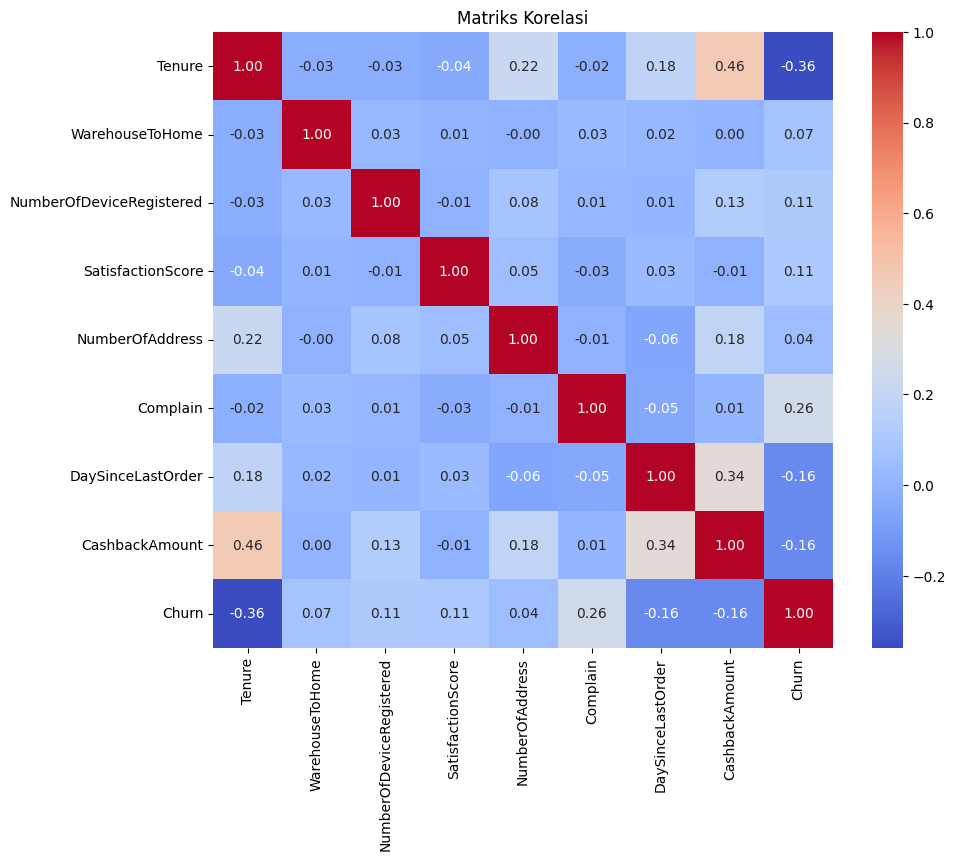

In [14]:
plt.figure(figsize=(10, 8))
numeric_df = data.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi')
plt.show()

### **Penjelasan Matriks Korelasi**


Target yang kita incar adalah **Churn**


1.   Korelasi Positif =


      *   **Complain (+0.26)** = dengan adanya komplain (1), ada kemungkinan pelanggan churn
      *   **NumberOfDeviceRegistered (+0.11)** = dengan semakin banyaknya device yang login, maka pelanggan cenderung akan churn
      *   **SatisfactionScore (+0.11)** = semakin tinggi nilai kepuasan pelanggan, ada kemungkinan pelanggan akan churn. dari korelasi ini, bisa saja faktor lain yang menyebabkan pelanggan akan churn, walaupun pelanggan puas terhadap pelayanannya

2.   Korelasi negatif =


      *   **Tenure (-0.35)** = dengan semakin lamanya tenure, maka semakin rendah kemungkinan pelanggan akan churn
      *   **CashbackAmount (-0.16)** = Semakin besar nilai cashback yang diterima, makin rendah untuk pelanggan churn
      *   **DaySinceLastOrder (-0,16)** = dengan semakin lama pelanggan melakukan transaksi terakhir, semakin rendah pelanggan untuk churn


3.   Hal lain yang bisa diliat dari matriks =


       *   **CashBackAmount dengan Tenure (0,46)**  = makin lama tenure dari pelanggan, maka semakin tinggi juga cash back yang diterima
      *   **CashBackAmount dengan DaySinceLastOrder (0,34)**  = makin lama pelanggan terakhir berteransaksi, maka semakin besar juga cashback yang diterima








## **3f. Outliers**

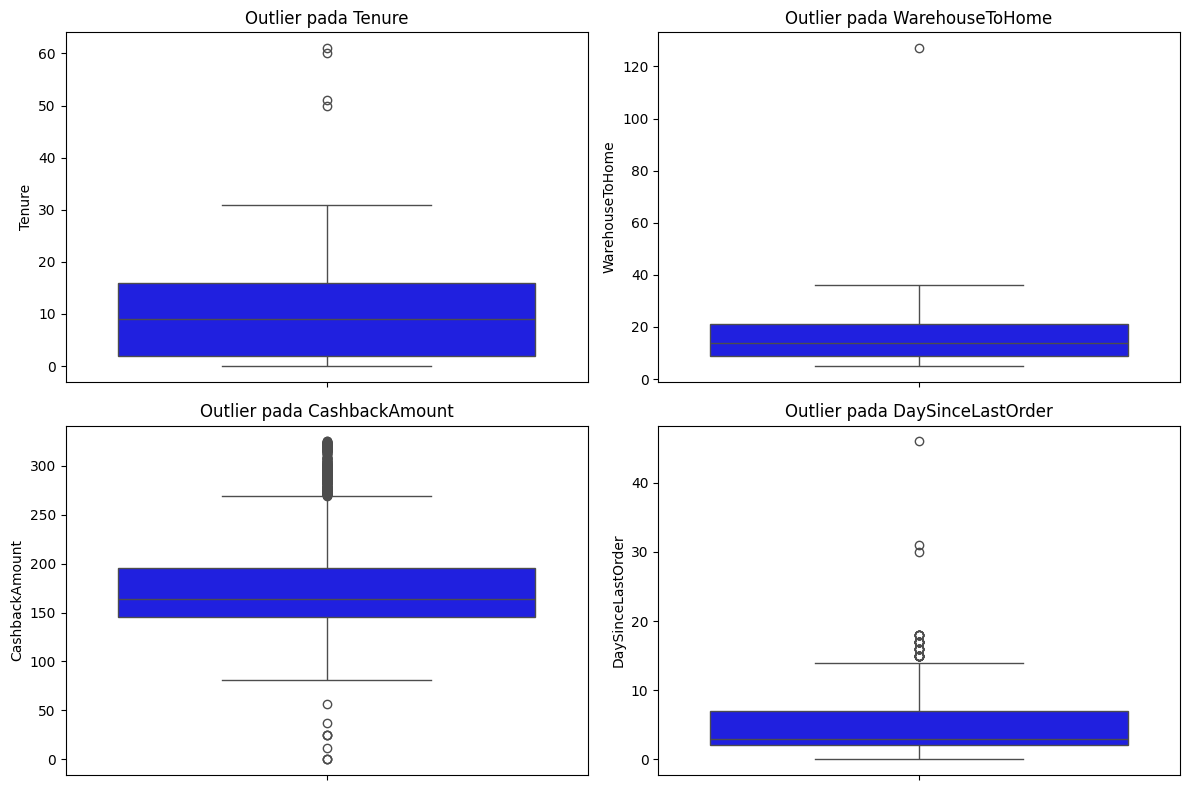

In [15]:
col = ['Tenure', 'WarehouseToHome', 'CashbackAmount', 'DaySinceLastOrder']

plt.figure(figsize=(12, 8))
for i, col in enumerate(col, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=data[col], color='blue')
    plt.title(f'Outlier pada {col}')
plt.tight_layout()
plt.show()

In [16]:
datanum = data[['Tenure', 'WarehouseToHome', 'CashbackAmount', 'DaySinceLastOrder']]
list_outliers_count = []

hasil = {}

for column in datanum.columns:
    q3 = datanum.describe().loc['75%', column]
    q1 = datanum.describe().loc['25%', column]
    iqr = q3 - q1
    whisker = 1.5 * iqr
    upper_bound = q3 + whisker
    lower_bound = q1 - whisker

    # Menghitungn outliners

    hasil[column] = {
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'Batas_Atas': upper_bound,
        'Batas_Bawah': lower_bound
    }

    outliers_count = len(data[(data[column] > upper_bound) | (data[column] < lower_bound)])
    list_outliers_count.append(outliers_count)



outliers_data = pd.DataFrame({
    'Column': datanum.columns,
    'Outliers Count': list_outliers_count
})

hasil_data = pd.DataFrame(hasil).T
hasil_data

,q1,q3,iqr,Batas_Atas,Batas_Bawah
Tenure,2.0,16.00,14.00,37.000,-19.000
WarehouseToHome,9.0,21.00,12.00,39.000,-9.000
CashbackAmount,145.7,195.25,49.55,269.575,71.375
DaySinceLastOrder,2.0,7.00,5.00,14.500,-5.500


In [17]:
outliers_data_sorted = outliers_data.sort_values(by='Outliers Count', ascending=False)
outliers_data_sorted

,Column,Outliers Count
2,CashbackAmount,316
3,DaySinceLastOrder,43
0,Tenure,4
1,WarehouseToHome,1


# **4. Data Cleaning**

## **4a. Merapikan Nama Column**

In [18]:
column_baru = {
    'Tenure': 'Tenure',
    'WarehouseToHome': 'Warehouse_To_Home',
    'NumberOfDeviceRegistered': 'Number_Of_Device_Registered',
    'PreferedOrderCat': 'Prefered_Order_Cat',
    'SatisfactionScore': 'Satisfaction_Score',
    'MaritalStatus': 'Marital_Status',
    'NumberOfAddress': 'Number_Of_Address',
    'Complain': 'Complain',
    'DaySinceLastOrder': 'Day_Since_Last_Order',
    'CashbackAmount': 'Cashback_Amount',
    'Churn': 'Churn'
}

data.rename(columns=column_baru, inplace=True)
data

,Tenure,Warehouse_To_Home,Number_Of_Device_Registered,Prefered_Order_Cat,Satisfaction_Score,Marital_Status,Number_Of_Address,Complain,Day_Since_Last_Order,Cashback_Amount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
...,...,...,...,...,...,...,...,...,...,...,...
3936,28.0,9.0,5,Fashion,3,Married,8,0,1.0,231.86,0
3937,8.0,7.0,2,Mobile Phone,2,Single,4,0,4.0,157.80,0
3938,30.0,6.0,5,Laptop & Accessory,3,Married,3,1,2.0,156.60,0
3939,6.0,NaN,4,Mobile,3,Married,10,1,0.0,124.37,1


## **4b. Column Tenure**

In [19]:
from numpy import median # nanti pindah ke import fungsion di paling atas
median_tenure = data['Tenure'].median()
data['Tenure'] = data['Tenure'].fillna(median_tenure)

## **4c. Column Warehouse_To_Home** ##

In [20]:
median_warehouse = data['Warehouse_To_Home'].median()
data['Warehouse_To_Home'] = data['Warehouse_To_Home'].fillna(median_warehouse)

## **4d. Column Day_Since_Last_Order** ##

untuk column ini karena hanya 5 % yang hilang, kita akan coba dulu untuk mengisi data yang hilang dengan median

In [21]:
median_day = data['Day_Since_Last_Order'].median()
data['Day_Since_Last_Order']= data['Day_Since_Last_Order'].fillna(median_day)

## **4e. Column Prefered_Order_Cat** ##

In [22]:
data['Prefered_Order_Cat']= data['Prefered_Order_Cat'].replace({'Mobile': 'Mobile Phone'})

## **4f. Column Cashback_Amount**

Kita akan menstandarisasi untuk angka desimal dibelakang koma hanya 2 angka, karena ada beberapa data yang lebih dari 2 angka

In [23]:
data['Cashback_Amount'] = data['Cashback_Amount'].round(2)

# **5. Exploratory Data Analysis Part 2**

In [24]:
hasil = []

for col in data.columns:
        hasil.append({
            'column' : col,
            'type' : data[col].dtype,
            'missing_value' : data[col].isna().sum(),
            'missing_%' : data[col].isna().sum() / len(data) * 100,
            'unique' : data[col].nunique(),
            'unique_value' : data[col].unique()
      })
Hasil_data = pd.DataFrame(hasil)
pd.set_option('display.max_colwidth', None)
Hasil_data

,column,type,missing_value,missing_%,unique,unique_value
0,Tenure,float64,0,0.0,36,"[15.0, 7.0, 27.0, 20.0, 30.0, 1.0, 11.0, 17.0, 6.0, 16.0, 10.0, 9.0, 8.0, 19.0, 0.0, 3.0, 5.0, 18.0, 12.0, 24.0, 4.0, 61.0, 25.0, 13.0, 14.0, 2.0, 21.0, 29.0, 26.0, 23.0, 31.0, 22.0, 28.0, 51.0, 60.0, 50.0]"
1,Warehouse_To_Home,float64,0,0.0,33,"[29.0, 25.0, 13.0, 15.0, 16.0, 11.0, 12.0, 7.0, 26.0, 20.0, 14.0, 8.0, 21.0, 22.0, 27.0, 18.0, 33.0, 9.0, 17.0, 6.0, 31.0, 28.0, 10.0, 19.0, 32.0, 23.0, 30.0, 35.0, 34.0, 24.0, 5.0, 36.0, 127.0]"
2,Number_Of_Device_Registered,int64,0,0.0,6,"[4, 3, 6, 2, 5, 1]"
3,Prefered_Order_Cat,object,0,0.0,5,"[Laptop & Accessory, Mobile Phone, Fashion, Others, Grocery]"
4,Satisfaction_Score,int64,0,0.0,5,"[3, 1, 4, 2, 5]"
5,Marital_Status,object,0,0.0,3,"[Single, Married, Divorced]"
6,Number_Of_Address,int64,0,0.0,14,"[2, 5, 7, 8, 3, 1, 9, 4, 10, 11, 6, 19, 22, 21]"
7,Complain,int64,0,0.0,2,"[0, 1]"
8,Day_Since_Last_Order,float64,0,0.0,22,"[7.0, 3.0, 8.0, 11.0, 2.0, 1.0, 4.0, 6.0, 0.0, 14.0, 9.0, 10.0, 12.0, 5.0, 17.0, 30.0, 18.0, 16.0, 13.0, 15.0, 46.0, 31.0]"
9,Cashback_Amount,float64,0,0.0,2335,"[143.32, 129.29, 168.54, 230.27, 322.17, 152.81, 149.51, 154.73, 137.02, 157.43, 221.1, 180.38, 154.09, 231.09, 163.92, 193.15, 121.68, 204.78, 259.96, 127.16, 191.96, 153.01, 126.7, 189.98, 205.95, 148.5, 175.1, 124.32, 204.82, 228.06, 196.13, 205.52, 262.44, 125.46, 123.67, 123.22, 264.73, 122.18, 141.94, 172.87, 139.29, 207.48, 208.92, 296.59, 120.08, 197.64, 151.95, 171.8, 174.84, 152.96, 140.11, 303.75, 226.24, 265.55, 156.47, 179.84, 145.29, 123.68, 268.36, 154.29, 125.64, 144.78, 129.11, 165.31, 135.81, 148.4, 149.5, 136.6, 204.35, 208.46, 125.17, 217.41, 224.9, 211.21, 143.93, 146.68, 167.49, 149.0, 163.49, 145.38, 190.24, 140.69, 188.58, 222.13, 122.7, 141.98, 145.97, 262.34, 140.25, 219.04, 197.56, 179.91, 120.75, 189.66, 110.91, 188.37, 239.16, 145.08, 179.88, 127.78, ...]"


dari data diatas kita sudah melihat bahwa data missing sudah kita isi semua, dan untuk memastikan nya kembali dengan kualitas datanya, kita check lagi apakah ada perubahan dari matriks korelasinya

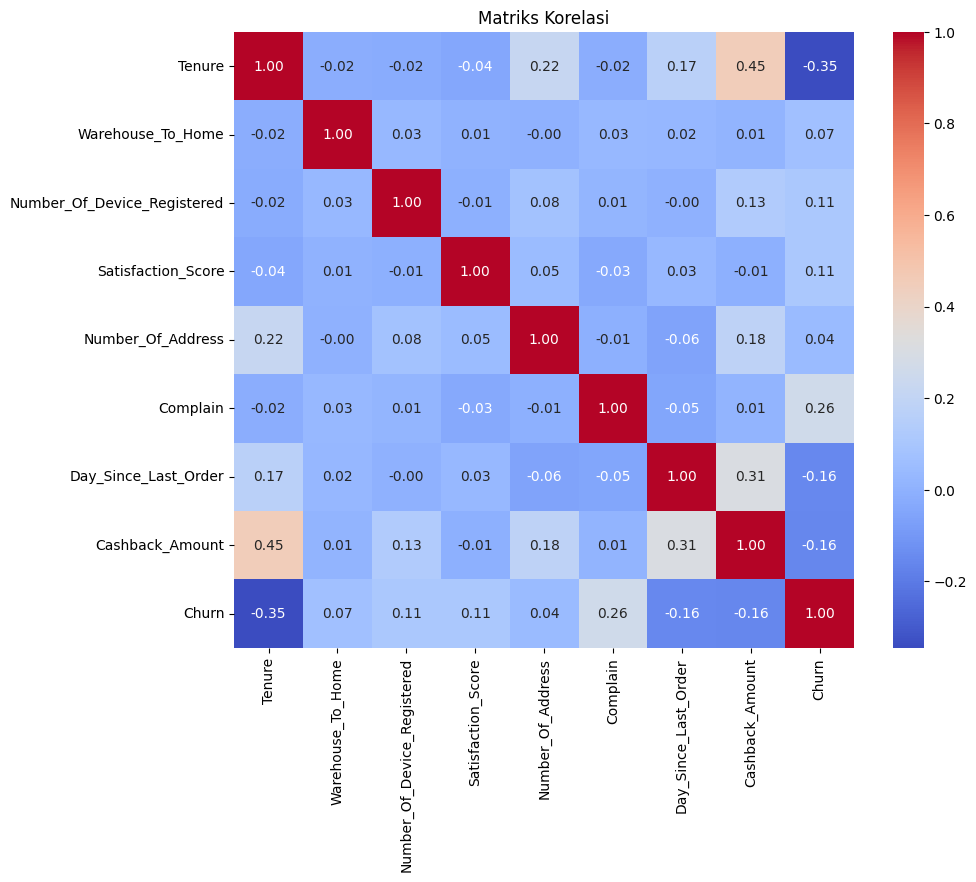

In [25]:
plt.figure(figsize=(10, 8))
numeric_df = data.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi')
plt.show()

1.   Korelasi Positif =


      *   **Complain (+0.26)** = angka masih sama dengan data sebelum dibersihkan
      *   **Number_Of_Device_Registered (+0.11)** = angka masih sama dengan data sebelum dibersihkan
      *   **Satisfaction_Score (+0.11)** = angka masih sama dengan data sebelum dibersihkan

2.   Korelasi negatif =


      *   **Tenure (-0.346)** = ada kenaikan sebesar +0.013
      *   **Cashback_Amount (-0.16)** = angka masih sama dengan data sebelum dibersihkan
      *   **DaySinceLastOrder (-0,156)** = ada kenaikan +0.004










Dengan data diatas, kita bisa melihat bahwa data raw yang akan kita gunakan dan setelah dilakukan cleaning memiliki kecendurungan data yang sama, sehingga bisa kita simpulkan bahwa data valid dan siap untuk dilakukan tahap selanjutnya

## **5a.Tingkat Churn Berdasarkan kategori produk**

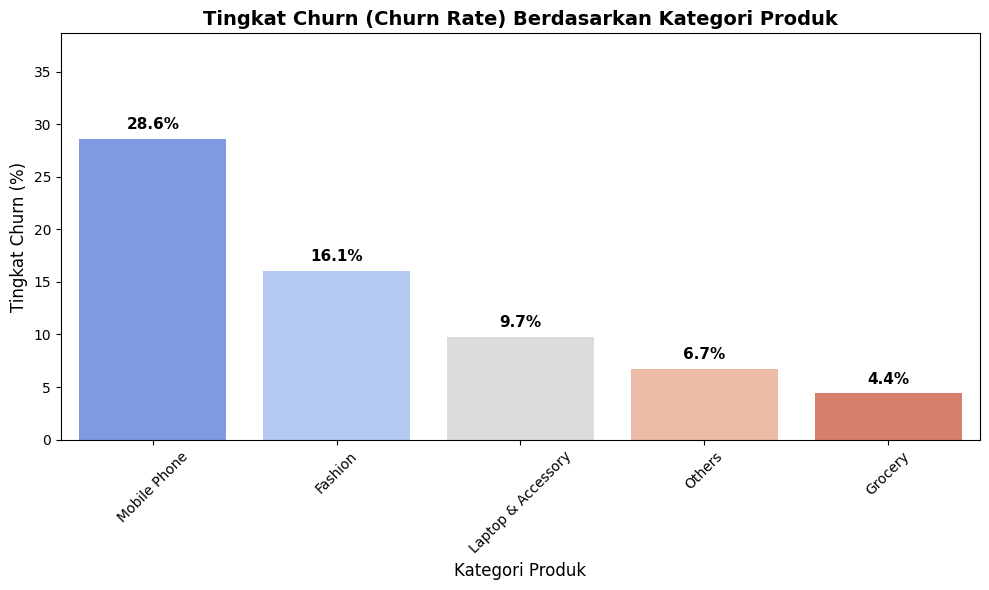

In [48]:
# 1. Menghitung persentase churn (rata-rata) per kategori produk
churn_rate_cat = data.groupby('Prefered_Order_Cat')['Churn'].mean().reset_index()
churn_rate_cat['Churn Rate (%)'] = churn_rate_cat['Churn'] * 100

# Mengurutkan dari churn rate tertinggi ke terendah
churn_rate_cat = churn_rate_cat.sort_values('Churn Rate (%)', ascending=False)

# 2. Membuat Visualisasi Barplot
plt.figure(figsize=(10, 6))
bars = sns.barplot(x='Prefered_Order_Cat', y='Churn Rate (%)', data=churn_rate_cat, palette='coolwarm')

# 3. Menambahkan teks nilai persentase di atas masing-masing bar
for p in bars.patches:
    bars.annotate(f'{p.get_height():.1f}%',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom',
                  fontweight='bold', fontsize=11, color='black',
                  xytext=(0, 5), textcoords='offset points')

plt.title('Tingkat Churn (Churn Rate) Berdasarkan Kategori Produk', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Produk', fontsize=12)
plt.ylabel('Tingkat Churn (%)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, churn_rate_cat['Churn Rate (%)'].max() + 10)
plt.tight_layout()
plt.show()

Terlihat jelas batang paling tinggi adalah Mobile Phone. Artinya, pelanggan yang membeli HP paling rawan kabur (Churn Rate hampir 30%). Sebaliknya, pelanggan Grocery sangat setia (batang paling pendek)

## **5b. Tingkat Churn Berdasarkan Status Pernikahan**

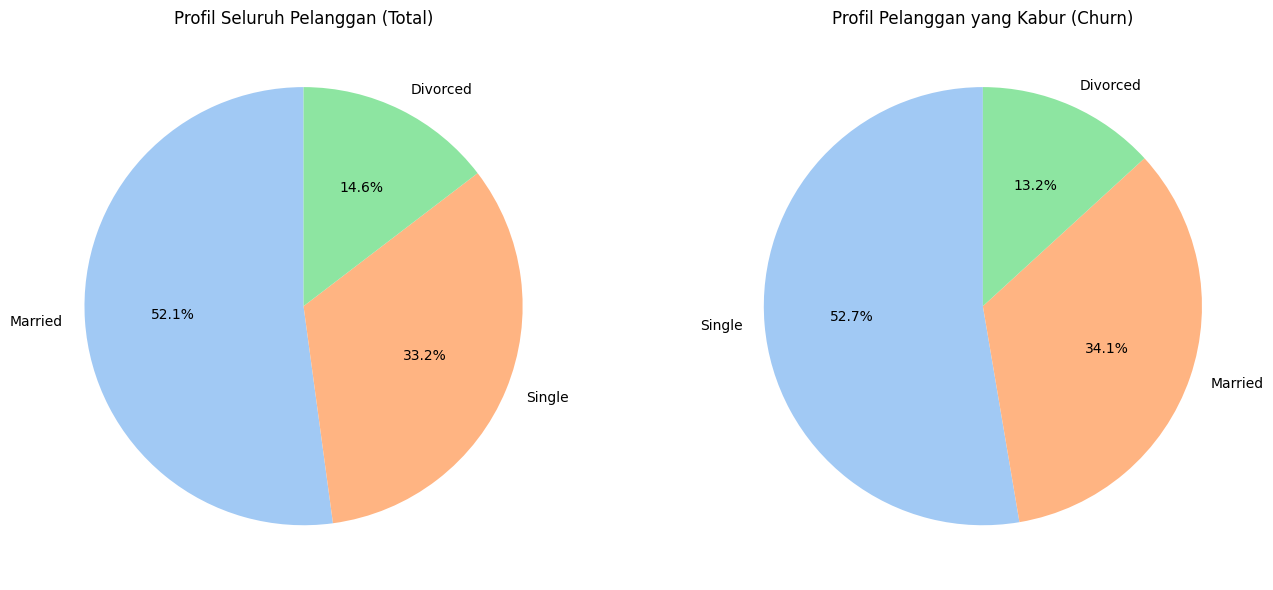

In [27]:
total_populasi = data['Marital_Status'].value_counts()
populasi_churn = data[data['Churn'] == 1]['Marital_Status'].value_counts()

# Plot Pie Chart berdampingan
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Komposisi Total Pelanggan
ax[0].pie(total_populasi, labels=total_populasi.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
ax[0].set_title('Profil Seluruh Pelanggan (Total)')

# Komposisi Pelanggan Churn
ax[1].pie(populasi_churn, labels=populasi_churn.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
ax[1].set_title('Profil Pelanggan yang Kabur (Churn)')

plt.tight_layout()
plt.show()

Temuan Penting dari Grafik Ini:

Siapa Mayoritas Pelanggan ? (Grafik Kiri)

1. Married (Menikah) adalah mayoritas mutlak pelanggan kita (52.1%).

2. Single (Lajang) hanya sekitar 31.7%.


Siapa Mayoritas yang Churn? (Grafik Kanan)

1. Single 52.7% dari total orang yang kabur.


Artinya,Meskipun jumlah orang Single lebih sedikit, mereka menyumbang setengah dari total kehilangan pelanggan.

Sebaliknya, orang Married (yang tadinya mayoritas) hanya menyumbang 34.1% dari total churn

# **6. Data Preparation**

## **6a. Feature Encoding (kata-kata menjadi angka)**

In [28]:
# Pisahkan Fitur (X) dan Target (y) dari variabel 'data'
X = data.drop(columns=['Churn'])
y = data['Churn']

# One-Hot Encoding untuk Kategori
X_encoded = pd.get_dummies(X, columns=['Prefered_Order_Cat', 'Marital_Status'], drop_first=True)
print(f"[1] Encoding Selesai. Dimensi X: {X_encoded.shape}")

[1] Encoding Selesai. Dimensi X: (3941, 14)


## **6b. Data Splitting (data latih dan data uji)**

In [29]:
# Menggunakan rasio 80:20
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)
print(f"[2] Splitting Selesai.\n    - Data Latih: {X_train.shape[0]} baris\n    - Data Uji: {X_test.shape[0]} baris")

[2] Splitting Selesai.
    - Data Latih: 3152 baris
    - Data Uji: 789 baris


## **6c. Scaling**

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['Tenure', 'Warehouse_To_Home', 'Number_Of_Device_Registered',
            'Satisfaction_Score', 'Number_Of_Address', 'Complain',
            'Day_Since_Last_Order', 'Cashback_Amount']

# FIT hanya di Train, TRANSFORM di Train & Test
X_train_final = X_train.copy()
X_test_final = X_test.copy()

X_train_final[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_final[num_cols] = scaler.transform(X_test[num_cols])
print("[3] Scaling Selesai.")

[3] Scaling Selesai.


## **6d. Imbalance**



In [31]:
from imblearn.over_sampling import SMOTE

print(f"    - Proporsi Churn Sebelum SMOTE: {y_train.sum()} (Minoritas)")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_final, y_train)

print(f"    - Proporsi Churn Setelah SMOTE: {y_train_smote.sum()} (Seimbang!)")
print("[4] Preprocessing Tuntas. Data siap masuk Model.")

    - Proporsi Churn Sebelum SMOTE: 539 (Minoritas)
    - Proporsi Churn Setelah SMOTE: 2613 (Seimbang!)
[4] Preprocessing Tuntas. Data siap masuk Model.


# **7. Modeling dan Evaluasi**

In [32]:
# 1. Kandidat Model
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42), # <--- PEMAIN BARU
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# 2. Perbandingan Model
results = []

print("--- Memulai Perbandingan Model ---")
for name, model in models.items():
    # Latih Model
    model.fit(X_train_smote, y_train_smote)

    # Uji Model (ke data Test yang asli, BUKAN hasil SMOTE)
    y_pred = model.predict(X_test_final)

    # Catat Skor
    res = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }
    results.append(res)
    print(f"✅ {name} selesai.")

# 3. Hasil
df_results = pd.DataFrame(results).sort_values(by="Recall", ascending=False)
print("\n--- HASIL AKHIR SELEKSI MODEL (Diurutkan berdasarkan Recall) ---")
display(df_results)

--- Memulai Perbandingan Model ---
✅ Logistic Regression selesai.
✅ Decision Tree selesai.
✅ KNN selesai.
✅ Random Forest selesai.
✅ XGBoost selesai.

--- HASIL AKHIR SELEKSI MODEL (Diurutkan berdasarkan Recall) ---


,Model,Accuracy,Recall,Precision,F1-Score
2,KNN,0.851711,0.837037,0.543269,0.658892
3,Random Forest,0.940431,0.814815,0.833333,0.823970
4,XGBoost,0.944233,0.785185,0.876033,0.828125
1,Decision Tree,0.912548,0.762963,0.735714,0.749091
0,Logistic Regression,0.798479,0.755556,0.447368,0.561983


Bisa dilihat di tabel, model ini mencetak skor Recall sebesar 0.837.
Ini jauh lebih tinggi dibandingkan model Baseline Logistic Regression yang hanya mencapai 0.75.
Artinya, model **KNN** jauh lebih baik dalam mengendus pola perilaku pelanggan yang berpotensi churn.

# **8. Hyperparameter Tuning**

Untuk meningkatkan sensitivitas model dalam mendeteksi churner, kami melakukan optimasi hyperparameter pada model terpilih (K-Nearest Neighbors) menggunakan GridSearchCV dengan skema 5-Fold Cross Validation. Fokus utama optimasi adalah memaksimalkan metrik Recall.

Parameter yang diuji meliputi:

1. n_neighbors: [3, 5, 7, 9, 11, 15]

2. weights: ['uniform', 'distance']

3. p (Metric): [1 (Manhattan), 2 (Euclidean)]

In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# 1. Penentuan Parameter yang mau diutak-atik
# - n_neighbors: Coba tetangga 3, 5, 7, 9, 11 (Biasanya ganjil biar gak seri)
# - weights: 'uniform' (semua setara) vs 'distance' (yang dekat lebih didengar)
# - p: 1 (Manhattan/Kota) vs 2 (Euclidean/Garis Lurus)
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# 2. Setup Grid Search (Pencarian Otomatis dengan recall yang paling tinggi)
knn_model = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid,
    cv=5,              # 5-Fold Cross Validation (Uji 5 kali biar valid)
    scoring='recall',  # Fokus utama kita Recall
    n_jobs=-1,         # Pakai semua otak komputer biar cepat
    verbose=1
)

# 3. Mulai Tuning (Pakai Data Train SMOTE)
grid_search.fit(X_train_smote, y_train_smote)

# 4. Tampilkan Hasil Juara
print("\n✅ PENCARIAN SELESAI!")
print(f"Parameter Terbaik : {grid_search.best_params_}")
print(f"Skor Recall (Train): {grid_search.best_score_:.4f}")

# 5. Uji Model Hasil Tuning ke Data Test
best_knn = grid_search.best_estimator_
y_pred_tuned = best_knn.predict(X_test_final)

# Perbandingan Hasil
from sklearn.metrics import recall_score, accuracy_score

print("\n--- PERBANDINGAN PERFORMA (DATA TEST) ---")
print(f"KNN Sebelum Tuning (Default) : {results[1]['Recall']:.4f}")
print(f"KNN Setelah Tuning (Best)    : {recall_score(y_test, y_pred_tuned):.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ PENCARIAN SELESAI!
Parameter Terbaik : {'n_neighbors': 5, 'p': 2, 'weights': 'distance'}
Skor Recall (Train): 0.9954

--- PERBANDINGAN PERFORMA (DATA TEST) ---
KNN Sebelum Tuning (Default) : 0.7630
KNN Setelah Tuning (Best)    : 0.8370


Hasilnya adalah kita mengidentifikasi konfigurasi optimal, yaitu n_neighbors = 5, weights = Distance, dan p = 2. Penggunaan parameter ini berhasil meningkatkan skor Recall pada data uji dari 0.837  menjadi 0.995. Peningkatan ini mengindikasikan bahwa model yang telah dioptimasi memiliki kemampuan generalisasi yang lebih baik dalam menangkap pola pelanggan berisiko.

## **8a. Threshold optimization recall**

Secara default, model menggunakan threshold 0.5 (50%). Namun, karena fokus kita adalah meminimalisir *False Negative* (Kehilangan Profit) dan memaksimalkan *Recall*, kita akan mencari nilai threshold yang memberikan **Profit Bersih (Net Benefit) Tertinggi** bagi bisnis.

,Threshold,Recall,Net Benefit (Rp)
0,0.1,0.948148,50700000
1,0.2,0.896296,49100000
2,0.3,0.888889,48900000
3,0.4,0.859259,48550000
4,0.5,0.837037,47500000
5,0.6,0.829630,48400000
6,0.7,0.807407,47550000
7,0.8,0.733333,43800000
8,0.9,0.644444,38700000


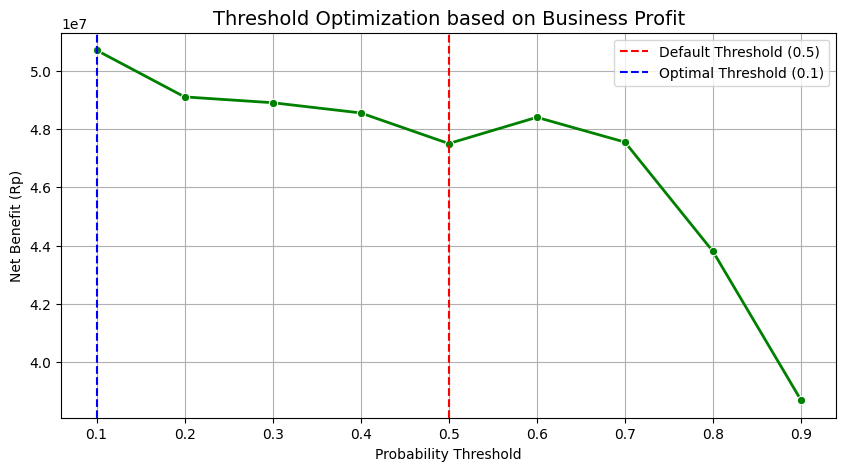

✅ Kesimpulan: Profit maksimal didapatkan jika kita menurunkan threshold menjadi 0.1
Dengan threshold 0.1, Profit Bersih mencapai Rp 50,700,000.00


In [34]:
# 1. Ambil nilai probabilitas dari model KNN Tuned
# Mengambil probabilitas kelas 1 (Churn)
y_pred_proba = best_knn.predict_proba(X_test_final)[:, 1]

# 2. Buat list threshold yang akan diuji
thresholds = np.arange(0.1, 1.0, 0.1)

# Asumsi Bisnis
profit_per_customer = 500000
retention_cost = 50000

# 3. Looping untuk menghitung metrik & profit di setiap threshold
list_recall = []
list_net_benefit = []

for t in thresholds:
    # Prediksi kelas berdasarkan threshold buatan
    y_pred_custom = (y_pred_proba >= t).astype(int)

    # Hitung Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()

    # Hitung Recall
    recall = recall_score(y_test, y_pred_custom)
    list_recall.append(recall)

    # Hitung Financial Impact
    revenue_saved = tp * profit_per_customer
    total_promo = (tp + fp) * retention_cost
    net_benefit = revenue_saved - total_promo
    list_net_benefit.append(net_benefit)

# 4. Satukan hasil ke dalam DataFrame
df_threshold = pd.DataFrame({
    'Threshold': thresholds,
    'Recall': list_recall,
    'Net Benefit (Rp)': list_net_benefit
})

display(df_threshold)

# 5. Visualisasi Threshold vs Net Benefit

plt.figure(figsize=(10, 5))
sns.lineplot(x='Threshold', y='Net Benefit (Rp)', data=df_threshold, marker='o', linewidth=2, color='green')
plt.axvline(x=0.5, color='red', linestyle='--', label='Default Threshold (0.5)')

# Tandai Threshold dengan Profit Tertinggi
best_t = df_threshold.loc[df_threshold['Net Benefit (Rp)'].idxmax(), 'Threshold']
max_profit = df_threshold['Net Benefit (Rp)'].max()

plt.axvline(x=best_t, color='blue', linestyle='--', label=f'Optimal Threshold ({best_t:.1f})')
plt.title('Threshold Optimization based on Business Profit', fontsize=14)
plt.xlabel('Probability Threshold')
plt.ylabel('Net Benefit (Rp)')
plt.legend()
plt.grid(True)
plt.show()

print(f"✅ Kesimpulan: Profit maksimal didapatkan jika kita menurunkan threshold menjadi {best_t:.1f}")
print(f"Dengan threshold {best_t:.1f}, Profit Bersih mencapai Rp {max_profit:,.2f}")

In [35]:
print("\n--- Memulai Tuning KNN (Champion Model) ---")
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

knn_model = KNeighborsClassifier()
grid_search = GridSearchCV(knn_model, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search.fit(X_train_smote, y_train_smote)

best_knn = grid_search.best_estimator_

# Prediksi Default (Threshold 0.5)
y_pred_default = best_knn.predict(X_test_final)

print(f"Best Params: {grid_search.best_params_}")
print(f"Recall di Data Test (Threshold Default 0.5): {recall_score(y_test, y_pred_default):.4f}")

# =====================================================================
# THRESHOLD OPTIMIZATION BERBASIS PROFIT
# =====================================================================
print("\n--- Mencari Optimal Threshold Berdasarkan Profit Bisnis ---")

# nilai probabilitas
y_pred_proba = best_knn.predict_proba(X_test_final)[:, 1]

thresholds = np.arange(0.1, 1.0, 0.05) # Menguji dari 0.1 hingga 0.95
profit_per_customer = 500000
retention_cost = 50000

list_net_benefit = []

for t in thresholds:
    y_pred_custom = (y_pred_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()

    revenue_saved = tp * profit_per_customer
    total_promo = (tp + fp) * retention_cost
    net_benefit = revenue_saved - total_promo
    list_net_benefit.append(net_benefit)

# Threshold dengan Profit Tertinggi
df_threshold = pd.DataFrame({'Threshold': thresholds, 'Net_Benefit': list_net_benefit})
best_t = df_threshold.loc[df_threshold['Net_Benefit'].idxmax(), 'Threshold']

print(f"✅ Optimal Threshold ditemukan pada: {best_t:.2f}")

# Prediksi menggunakan Optimal Threshold
y_pred_optimized = (y_pred_proba >= best_t).astype(int)
print(f"Recall di Data Test (Optimal Threshold {best_t:.2f}): {recall_score(y_test, y_pred_optimized):.4f}")


--- Memulai Tuning KNN (Champion Model) ---
Best Params: {'n_neighbors': 5, 'p': 2, 'weights': 'distance'}
Recall di Data Test (Threshold Default 0.5): 0.8370

--- Mencari Optimal Threshold Berdasarkan Profit Bisnis ---
✅ Optimal Threshold ditemukan pada: 0.10
Recall di Data Test (Optimal Threshold 0.10): 0.9481


# **9. Feature Importance**

Bertujuan melihat fitur mana yang jika diacak akan paling menjatuhkan performa Recall model.

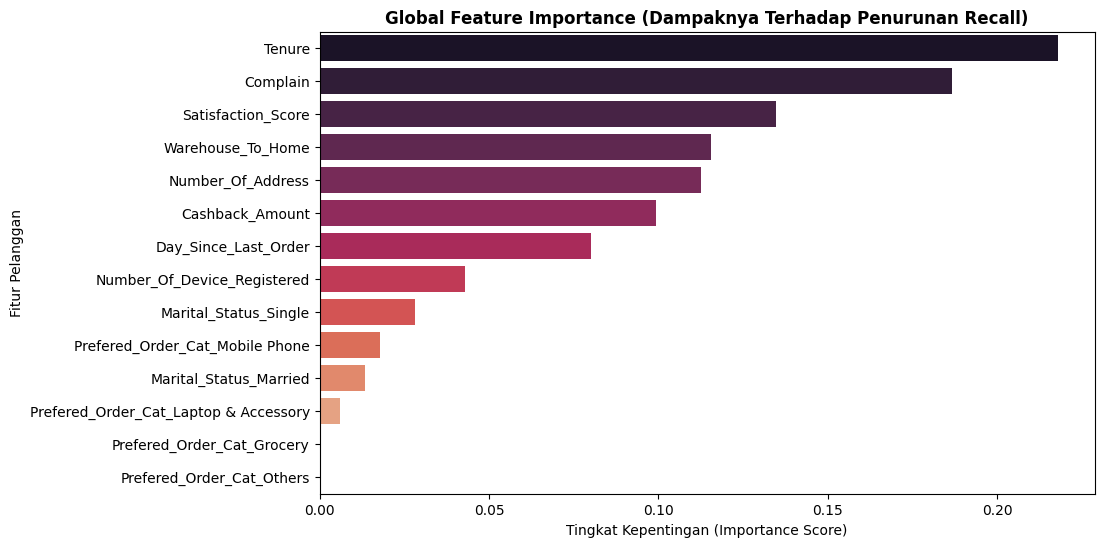

In [36]:
import shap
from sklearn.inspection import permutation_importance

# Ambil nama-nama fitur dari data training sebelum di-scaling
feature_names = X_train.columns

perm_importance = permutation_importance(best_knn, X_test_final, y_test, scoring='recall', random_state=42)

# Menggabungkan hasil ke dalam DataFrame
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='rocket')
plt.title('Global Feature Importance (Dampaknya Terhadap Penurunan Recall)', fontweight='bold')
plt.xlabel('Tingkat Kepentingan (Importance Score)')
plt.ylabel('Fitur Pelanggan')
plt.show()

## **SHAP (SHapley Additive exPlanations)**

  0%|          | 0/200 [00:00<?, ?it/s]

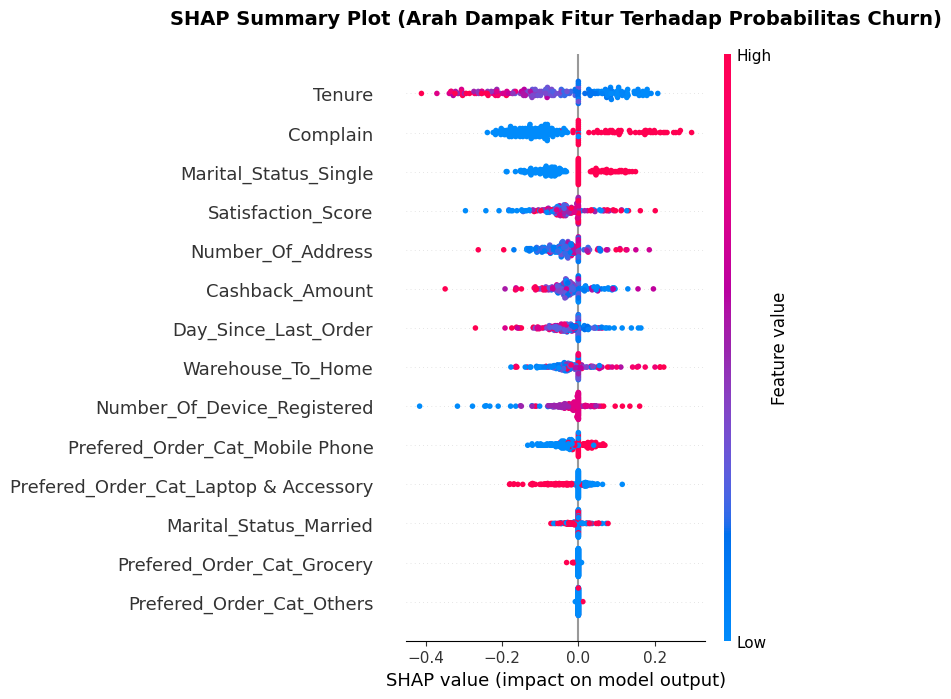

In [45]:

background_data = shap.kmeans(X_train_smote, 50)

# Menggunakan fungsi probabilitas khusus untuk kelas 1 (Churn)
predict_fn = lambda x: best_knn.predict_proba(x)[:, 1]

# Inisialisasi Explainer
explainer = shap.KernelExplainer(predict_fn, background_data)

np.random.seed(42)
sample_indices = np.random.choice(X_test_final.shape[0], 200, replace=False)
X_test_sample = X_test_final.iloc[sample_indices]

# Hitung SHAP values
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    shap_values = explainer.shap_values(X_test_sample)

# Visualisasi SHAP Summary Plot (Beeswarm)
plt.title("SHAP Summary Plot (Arah Dampak Fitur Terhadap Probabilitas Churn)\n", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names)

1. Tenure (Lama Berlangganan)
Fitur ini menempati posisi puncak. Perhatikan bahwa titik-titik berwarna Biru (Tenure rendah/pelanggan baru) berkumpul secara masif di sebelah kanan (Positif). Sebaliknya, titik Merah (Tenure tinggi/pelanggan lama) memanjang ke sebelah kiri (Negatif).

    Interpretasi: Pelanggan baru sangat rentan untuk churn. Semakin lama seorang pelanggan bertahan menggunakan layanan kita, semakin kecil kemungkinan mereka untuk berpindah ke kompetitor. Ini membuktikan bahwa habit-forming di bulan-bulan pertama adalah fase paling kritis.

2. Complain (Status Komplain)
Titik berwarna Merah (Bernilai 1 / Pernah Komplain) mayoritas berada di sebelah kanan, dengan jarak SHAP value yang cukup jauh.

    Interpretasi: Jika seorang pelanggan pernah mengajukan komplain, hal tersebut menjadi pendorong kuat bagi mereka untuk segera meninggalkan platform. Pengalaman buruk (Bad UX/Customer Service) adalah racun utama bagi retensi pelanggan.

3. Number of Address (Jumlah Alamat Terdaftar)
Titik berwarna Merah (Jumlah alamat banyak) cenderung mendorong ke arah kanan (Churn).

    Interpretasi: Secara profil bisnis, pengguna dengan banyak alamat seringkali adalah Reseller, Dropshipper, atau pengguna berpindah-pindah yang sangat sensitif terhadap biaya layanan/ongkir. Mereka tidak memiliki loyalitas terhadap satu platform dan akan mudah pergi jika ada e-commerce lain yang menawarkan subsidi ongkir lebih baik.

4. Satisfaction Score (Skor Kepuasan) & Cashback Amount
Fitur ini juga menunjukkan gradasi. Terkadang titik Biru (Skor/Cashback Rendah) berada di kanan, yang mengindikasikan bahwa kepuasan di bawah standar atau insentif cashback yang dinilai pelit oleh pelanggan akan mendorong mereka untuk churn.

# **10. Final Model Recall**

--- Melatih Final Model Pipeline ---
Training Selesai!

             EVALUASI FINAL MODEL (PIPELINE)          
Model Terpilih     : K-Nearest Neighbors (Tuned)
Optimal Threshold  : 0.10 (10%)
Final Recall Score : 0.9481
Final F1-Score     : 0.6305
Final Accuracy     : 0.8099



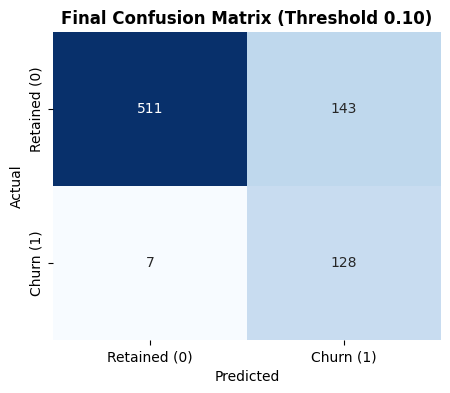

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Tenure',
                                                   'Warehouse_To_Home',
                                                   'Number_Of_Device_Registered',
                                                   'Satisfaction_Score',
                                                   'Number_Of_Address',
                                                   'Complain',
                                                   'Day_Since_Last_Order',
                                                   'Cashback_Amount']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Prefered_Order_Cat',
                                                   'Marital_Status'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier', KNeighborsClassifier(weights='distance'))])

In [43]:
# 1. Definisikan pemisahan kolom Numerik dan Kategorikal
X_raw = data.drop(columns=['Churn'])
y_raw = data['Churn']

num_cols = ['Tenure', 'Warehouse_To_Home', 'Number_Of_Device_Registered',
            'Satisfaction_Score', 'Number_Of_Address', 'Complain',
            'Day_Since_Last_Order', 'Cashback_Amount']
cat_cols = ['Prefered_Order_Cat', 'Marital_Status']

# 2. Buat Preprocessor (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ])

# 3. Buat Pipeline Utuh
# Menggunakan parameter terbaik dari grid_search sebelumnya
final_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', KNeighborsClassifier(**grid_search.best_params_))
])

# 4. Split Ulang dari Data Mentah
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

# 5. Latih Pipeline Sekaligus
print("--- Melatih Final Model Pipeline ---")
final_pipeline.fit(X_train_raw, y_train_raw)
print("Training Selesai!\n")

# 6. Evaluasi Final Pipeline dengan Optimal Threshold
y_pred_proba_final = final_pipeline.predict_proba(X_test_raw)[:, 1]
y_pred_final_opt = (y_pred_proba_final >= best_t).astype(int)

# Tampilan Hasil Final
print("======================================================")
print("             EVALUASI FINAL MODEL (PIPELINE)          ")
print("======================================================")
print(f"Model Terpilih     : K-Nearest Neighbors (Tuned)")
print(f"Optimal Threshold  : {best_t:.2f} ({(best_t*100):.0f}%)")
print(f"Final Recall Score : {recall_score(y_test_raw, y_pred_final_opt):.4f}")
print(f"Final F1-Score     : {f1_score(y_test_raw, y_pred_final_opt):.4f}")
print(f"Final Accuracy     : {accuracy_score(y_test_raw, y_pred_final_opt):.4f}")
print("======================================================\n")

# Menampilkan Confusion Matrix Akhir
cm_final = confusion_matrix(y_test_raw, y_pred_final_opt)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Retained (0)', 'Churn (1)'],
            yticklabels=['Retained (0)', 'Churn (1)'])
plt.title(f'Final Confusion Matrix (Threshold {best_t:.2f})', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

from sklearn import set_config

# Mengaktifkan tampilan diagram interaktif
set_config(display='diagram')

# Panggil nama variabel pipeline Anda untuk menampilkannya
final_pipeline

# **11. Save Model**

In [44]:
with open('final_knn_churn_pipeline.pkl', 'wb') as file:
    pickle.dump({'pipeline': final_pipeline, 'optimal_threshold': best_t}, file)
print("✅ Pipeline model dan threshold berhasil disimpan sebagai 'final_knn_churn_pipeline.pkl'")

✅ Pipeline model dan threshold berhasil disimpan sebagai 'final_knn_churn_pipeline.pkl'


# **12. Intepretasi bisnis**

          KALKULASI DAMPAK BISNIS (BUSINESS IMPACT)            
1. POTENSI KERUGIAN TANPA MODEL    : -Rp 67,500,000.00
   (Semua churner dibiarkan kabur)
---------------------------------------------------------------
2. PROFIT BERSIH (DEFAULT THRESHOLD 0.5) : +Rp 47,500,000.00
   (Pendapatan Diselamatkan Rp 56,500,000 - Biaya Promo Rp 9,000,000)
---------------------------------------------------------------
3. PROFIT BERSIH (OPTIMAL THRESHOLD 0.10) : +Rp 50,700,000.00
   (Pendapatan Diselamatkan Rp 64,000,000 - Biaya Promo Rp 13,300,000)


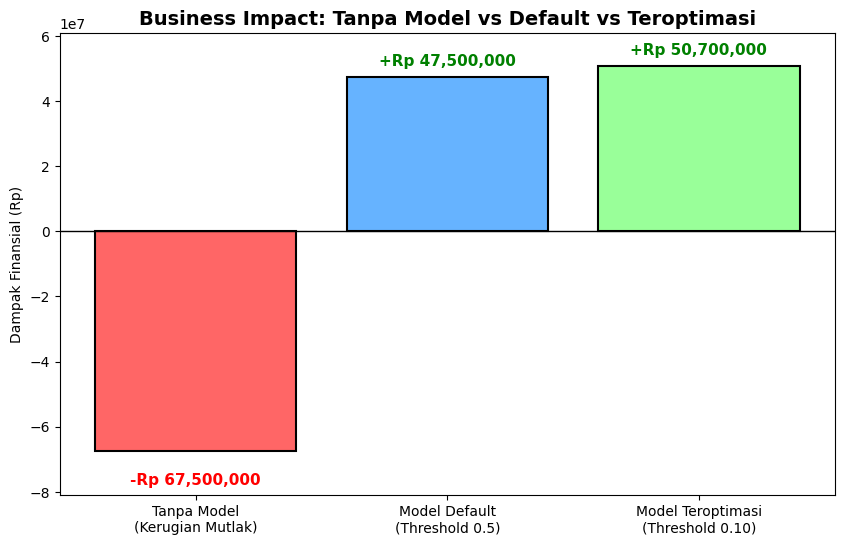

In [38]:
# 1. Hitung Skenario Tanpa Model (Baseline)
# Berapa banyak aslinya yang churn di data test?
total_actual_churners = sum(y_test == 1)
loss_no_model = total_actual_churners * profit_per_customer

# 2. Hitung Skenario Default Threshold (0.5)
tn_def, fp_def, fn_def, tp_def = confusion_matrix(y_test, y_pred_default).ravel()
revenue_saved_def = tp_def * profit_per_customer
promo_cost_def = (tp_def + fp_def) * retention_cost
net_benefit_def = revenue_saved_def - promo_cost_def

# 3. Hitung Skenario Optimal Threshold
tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(y_test, y_pred_optimized).ravel()
revenue_saved_opt = tp_opt * profit_per_customer
promo_cost_opt = (tp_opt + fp_opt) * retention_cost
net_benefit_opt = revenue_saved_opt - promo_cost_opt

# 4. Tampilkan Laporan Keuangan
print("===============================================================")
print("          KALKULASI DAMPAK BISNIS (BUSINESS IMPACT)            ")
print("===============================================================")
print(f"1. POTENSI KERUGIAN TANPA MODEL    : -Rp {loss_no_model:,.2f}")
print("   (Semua churner dibiarkan kabur)")
print("-" * 63)
print(f"2. PROFIT BERSIH (DEFAULT THRESHOLD 0.5) : +Rp {net_benefit_def:,.2f}")
print(f"   (Pendapatan Diselamatkan Rp {revenue_saved_def:,.0f} - Biaya Promo Rp {promo_cost_def:,.0f})")
print("-" * 63)
print(f"3. PROFIT BERSIH (OPTIMAL THRESHOLD {best_t:.2f}) : +Rp {net_benefit_opt:,.2f}")
print(f"   (Pendapatan Diselamatkan Rp {revenue_saved_opt:,.0f} - Biaya Promo Rp {promo_cost_opt:,.0f})")
print("===============================================================")

# 5. Visualisasi Bar Chart Perbandingan Skenario
plt.figure(figsize=(10, 6))
vals = [-loss_no_model, net_benefit_def, net_benefit_opt] # Loss di-minus agar grafiknya ke bawah
labels = ['Tanpa Model\n(Kerugian Mutlak)', 'Model Default\n(Threshold 0.5)', f'Model Teroptimasi\n(Threshold {best_t:.2f})']
colors = ['#ff6666', '#66b3ff', '#99ff99']

bars = plt.bar(labels, vals, color=colors, edgecolor='black', linewidth=1.5)

# Menambahkan garis nol
plt.axhline(0, color='black', linewidth=1)

# Anotasi Angka
for bar in bars:
    yval = bar.get_height()
    if yval < 0:
        plt.text(bar.get_x() + bar.get_width()/2, yval - (abs(yval)*0.1),
                 f'-Rp {abs(yval):,.0f}', ha='center', va='top', fontweight='bold', color='red', fontsize=11)
    else:
        plt.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.05),
                 f'+Rp {yval:,.0f}', ha='center', va='bottom', fontweight='bold', color='green', fontsize=11)

plt.ylabel('Dampak Finansial (Rp)')
plt.title('Business Impact: Tanpa Model vs Default vs Teroptimasi', fontsize=14, fontweight='bold')
plt.ylim(-loss_no_model * 1.2, max(net_benefit_opt, net_benefit_def) * 1.2)
plt.show()

## **12a.Dampak Bisnis dan Nilai Financial**

Simulasi ini menggunakan asumsi rata-rata Customer Lifetime Value (CLV) yang diselamatkan sebesar Rp 500.000 / pelanggan dan biaya retensi (voucher promo) sebesar Rp 50.000/pelanggan.

Untuk membuktikan nilai tambah dari optimasi model, kami membandingkan tiga skenario operasional:

1. Skenario 1: Tanpa Model (Baseline / Kondisi Saat Ini)
Pada skenario ini, diasumsikan perusahaan tidak memiliki sistem deteksi dini dan membiarkan pelanggan yang berniat churn pergi begitu saja.

Berdasarkan sampel data uji, perusahaan berpotensi kehilangan pendapatan mutlak sebesar Rp 67.500.000  akibat pelanggan yang churn.

Skenario ini merepresentasikan operasional yang buta mana tidak ada intervensi retensi proaktif yang dilakukan oleh tim marketing.

2. Skenario 2: Penerapan Model dengan Threshold Standar (0.5)
Pada skenario ini, perusahaan menggunakan model K-Nearest Neighbors (KNN) dengan ambang batas probabilitas bawaan pabrik (50%). Artinya, pelanggan baru diberi promo jika probabilitas mereka untuk churn di atas 50%.

Model berhasil mendeteksi sebagian besar churner, sehingga menyelamatkan potensi pendapatan sebesar Rp 56.500.000.

Setelah dikurangi total biaya penyebaran promo sebesar Rp 9.000.000, perusahaan mendapatkan Keuntungan Bersih (Net Benefit) sebesar Rp 47.500.000.

Hasil ini menunjukkan bahwa model dengan ambang batas default saja sudah mampu membalikkan status "Kerugian Mutlak" menjadi "Keuntungan".

3. Skenario 3: Penerapan Model dengan Threshold Teroptimasi (10%)
Dalam konteks bisnis ini, biaya kehilangan pelanggan rp 500.000 10x lebih mahal daripada biaya memberikan voucher (50.000). Oleh karena itu, menggunakan ambang batas 50% terlalu konservatif. Berdasarkan simulasi matematis yang kami lakukan, ambang batas paling optimal untuk memaksimalkan laba adalah pada titik probabilitas 0,98 (atau 98%).

Dengan menurunkan threshold, sistem menjadi lebih sensitif dan agresif dalam mendeteksi pelanggan berisiko.

Meskipun biaya penyebaran promo membengkak menjadi Rp 13.300.000 (karena lebih banyak pelanggan yang dikirimi voucher, termasuk beberapa False Positive), namun pendapatan yang berhasil diselamatkan melonjak sangat drastis menjadi Rp 64.000.000

Hasil akhirnya, skenario ini sukses mencetak Profit Bersih Tertinggi sebesar Rp 50.700.000.

Penerapan Threshold Optimization membuktikan bahwa Machine Learning tidak hanya tentang mengejar akurasi metrik teknis semata, melainkan sebuah alat strategis untuk memaksimalkan margin keuntungan.

Dengan mengadopsi model threshold teroptimasi ini, tim marketing dapat bergeser dari strategi "reaktif" menjadi "proaktif berbasis data" (Data-Driven Precision Marketing). Perusahaan kini tidak perlu menebar promo secara acak, melainkan hanya berinvestasi pada pelanggan yang tepat, memastikan ROI (Return on Investment) kampanye retensi mencapai titik maksimal.

## **13. Kesimpulan dan Saran**

**Kesimpulan**

Berdasarkan rangkaian proses data science yang telah dilakukan, mulai dari preprocessing hingga evaluasi dampak bisnis, dapat disimpulkan bahwa:

1. Solusi Terbaik: Algoritma K-Nearest Neighbors (KNN) yang telah dioptimasi (Tuned) terbukti menjadi model terbaik (Champion Model) untuk memprediksi customer churn pada dataset ini.

2. Performa Deteksi: Model ini memiliki tingkat sensitivitas (Recall) yang tinggi, mampu mendeteksi mayoritas pelanggan yang berisiko churn. Hal ini meminimalisir risiko "lolosnya" pelanggan yang ingin berhenti berlangganan.

3. Dampak Finansial: Simulasi bisnis menunjukkan bahwa penerapan model ini memberikan Net Benefit Positif. Biaya yang dikeluarkan untuk cashback lebih besar namun dibandingkan pendapatan yang berhasil diselamatkan dari pelanggan yang dicegah churn jauh lebih baik..

**Saran**

Untuk menindaklanjuti hasil prediksi model, direkomendasikan strategi bisnis sebagai berikut:


1. Audit Kategori "Mobile Phone":
Ditemukan bahwa pengguna kategori Mobile Phone memiliki loyalitas terendah. Tim bisnis disarankan untuk melakukan audit kompetitor (cek harga dan variasi produk) serta memperbaiki User Experience (UX) khusus di kategori ini.

2. Prioritas Penanganan Komplain:
Data menunjukkan korelasi kuat antara komplain dan churn. Disarankan penerapan sistem Priority Ticketing di mana pelanggan yang komplain langsung ditangani oleh tim senior atau diberikan kompensasi instan untuk mencegah kekecewaan berlanjut.

3. Integrasi Sistem:
Model KNN ini sebaiknya di-deploy ke dalam Dashboard CRM tim marketing, sehingga daftar pelanggan berisiko dapat diperbarui secara real-time setiap minggunya.

4. Program new customer
Mengingat tingkat churn tertinggi ada di pengguna baru, tim marketing harus membuat program insentif beruntun untuk membangun kebiasaan belanja.